<a href="https://colab.research.google.com/github/Harshan18-k/Harshan-codeboosters-2026/blob/main/day3_mini_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
API_KEY = "a59a2f8ba2d8c17e32d31372c1e430de"

In [ ]:
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

In [ ]:
Cities = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']
print("API configured for ",len(Cities),"cities")
print("Cities :",Cities)


API configured for  8 cities
Cities : ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [ ]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')

In [ ]:
import pandas as pd

print("Fetching weather data for all cities...")
print("")

all_cities_weather_data = []
for city_name in Cities:
  city_weather = fetch_weather(city_name, API_KEY)
  if city_weather:
    all_cities_weather_data.append(city_weather)
  else:
    print(f'Could not fetch weather data for {city_name}')

print("")
print("-"*80)

if all_cities_weather_data:
  pdf = pd.DataFrame(all_cities_weather_data)
  print(pdf)
else:
  print("No weather data was successfully fetched for any city.")

Fetching weather data for all cities...


--------------------------------------------------------------------------------
        city  temperature       description  humidity  wind_speed  pressure  \
0     Mumbai         34.0              haze        59        6.17      1009   
1      Delhi         44.0         clear sky        10        5.14       999   
2  Bangalore         29.8  scattered clouds        55        4.63      1009   
3    Chennai         36.0        few clouds        54        5.14      1005   
4  Hyderabad         31.2     broken clouds        51        8.75      1008   
5    Kolkata         32.0              haze        62        4.12      1001   
6       Pune         36.9   overcast clouds        27        3.76      1008   
7     Jaipur         42.6              haze        15        5.14      1001   

          condition  visibility  
0              Haze           7  
1         Clear Sky           7  
2  Scattered Clouds           8  
3        Few Clouds          

In [ ]:
import pandas as pd

print("Fetching weather data for all cities...")
print("")
chennai_city = fetch_weather(Cities[3],API_KEY)
if chennai_city:
  print(chennai_city)
else:
  print("No weather data was successfully fetched for Chennai.")
print("")
print("-"*80)
pdf = pd.DataFrame([chennai_city])
print(pdf)

Fetching weather data for all cities...

{'city': 'Chennai', 'temperature': 35.8, 'description': 'few clouds', 'humidity': 53, 'wind_speed': 5.14, 'pressure': 1005, 'condition': 'Few Clouds', 'visibility': 6}

--------------------------------------------------------------------------------
      city  temperature description  humidity  wind_speed  pressure  \
0  Chennai         35.8  few clouds        53        5.14      1005   

    condition  visibility  
0  Few Clouds           6  


In [ ]:
Cities.append('New York')
print(Cities)

['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur', 'New York']


In [ ]:
NewYork_city = fetch_weather(Cities[8],API_KEY)
if NewYork_city:
  print(NewYork_city)
else:
  print("No weather data was successfully fetched for New York.")

{'city': 'New York', 'temperature': 19.7, 'description': 'clear sky', 'humidity': 78, 'wind_speed': 3.6, 'pressure': 1013, 'condition': 'Clear Sky', 'visibility': 10}


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
if len(all_cities_weather_data)==0:
  print("Using fallback data for plotting")
else:
  data = all_cities_weather_data
  pdf = pd.DataFrame(all_cities_weather_data)
  print(pdf)
  print("-"*80)
  print(pdf.to_string(index=False))
  print(f"\nShape : ",pdf.shape)
  print("-"*80)
  print(f"\nMissing Values : ",pdf.isnull().sum())
  print("-"*80)
  print(f'\nData Types : ')
  print(pdf.dtypes)

        city  temperature       description  humidity  wind_speed  pressure  \
0     Mumbai         34.0              haze        59        6.17      1009   
1      Delhi         44.0         clear sky        10        5.14       999   
2  Bangalore         29.8  scattered clouds        55        4.63      1009   
3    Chennai         36.0        few clouds        54        5.14      1005   
4  Hyderabad         31.2     broken clouds        51        8.75      1008   
5    Kolkata         32.0              haze        62        4.12      1001   
6       Pune         36.9   overcast clouds        27        3.76      1008   
7     Jaipur         42.6              haze        15        5.14      1001   

          condition  visibility  
0              Haze           7  
1         Clear Sky           7  
2  Scattered Clouds           8  
3        Few Clouds           6  
4     Broken Clouds           6  
5              Haze           5  
6   Overcast Clouds          10  
7              H

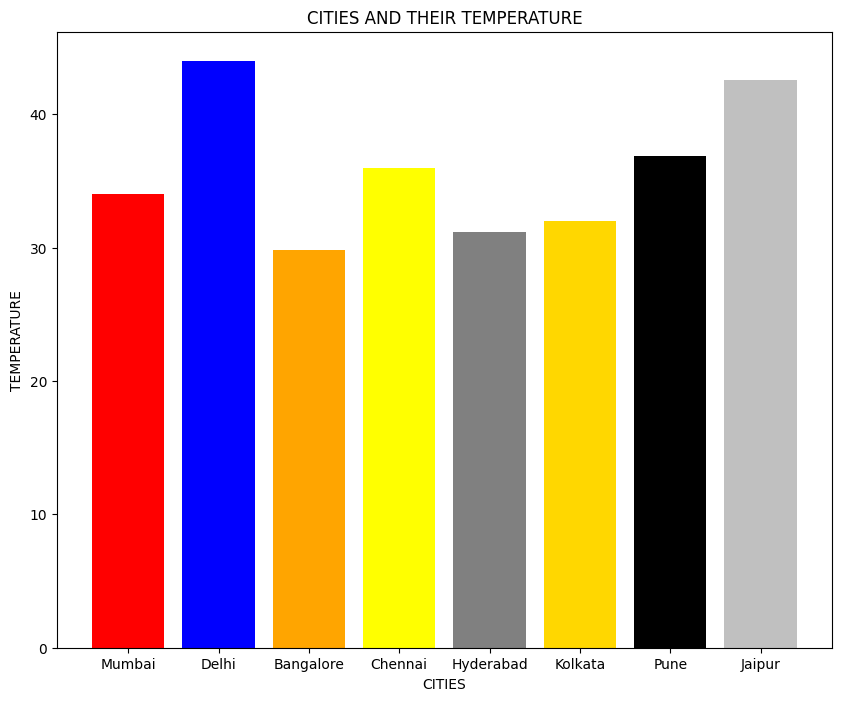

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig , ax = plt.subplots(figsize = (10,8))
plt.xlabel("CITIES")
plt.ylabel("TEMPERATURE")
plt.title("CITIES AND THEIR TEMPERATURE")
plt.bar(pdf['city'],pdf['temperature'],color = ['red','blue','orange','yellow','grey','gold','black','silver'])
plt.show()

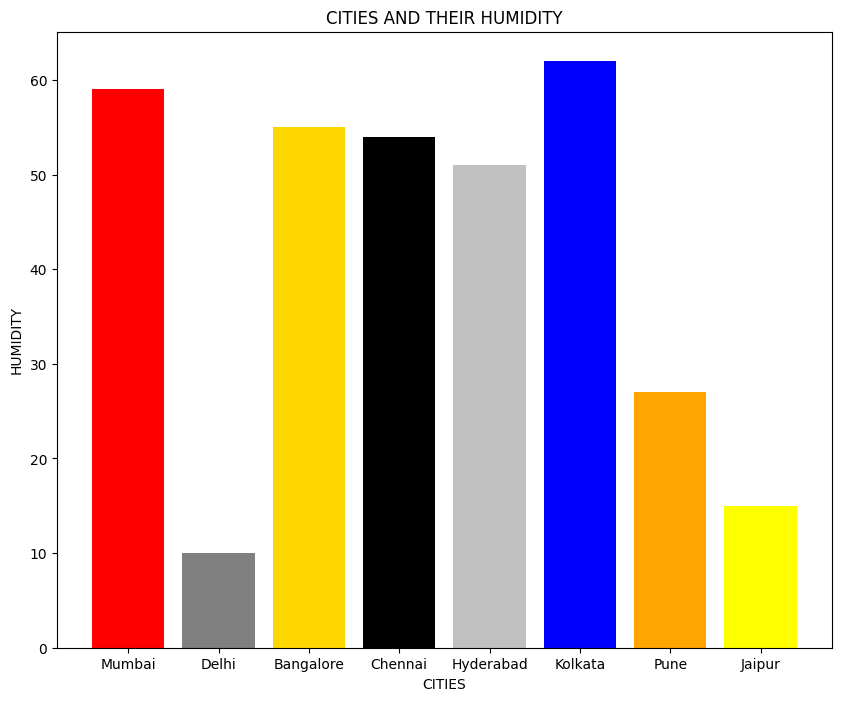

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig , ax = plt.subplots(figsize = (10,8))
plt.xlabel("CITIES")
plt.ylabel("HUMIDITY")
plt.title("CITIES AND THEIR HUMIDITY")
plt.bar(pdf['city'],pdf['humidity'],color = ['red','grey','gold','black','silver','blue','orange','yellow'])
plt.show()

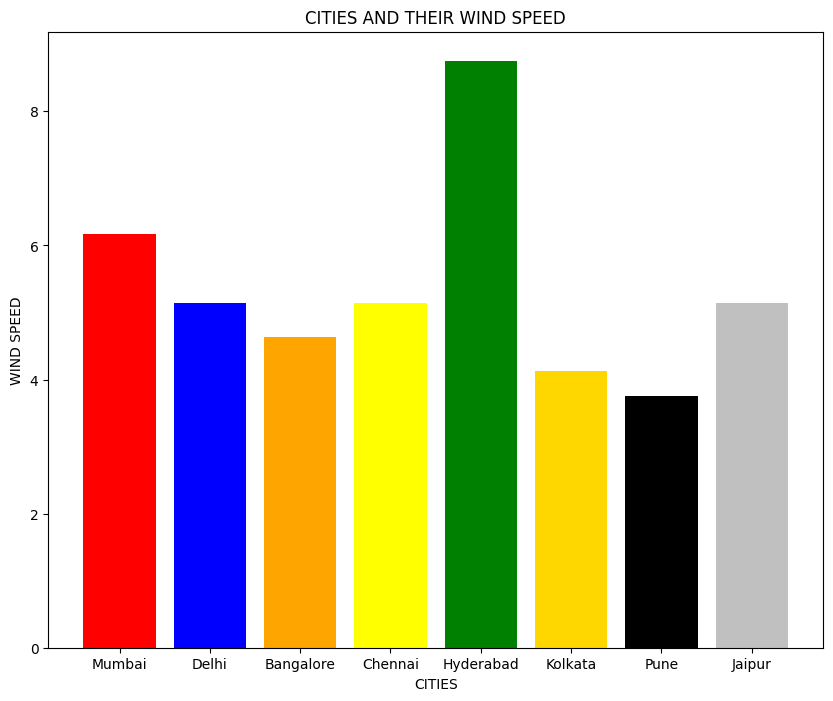

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig , ax = plt.subplots(figsize = (10,8))
plt.xlabel("CITIES")
plt.ylabel("WIND SPEED")
plt.title("CITIES AND THEIR WIND SPEED")
plt.bar(pdf['city'],pdf['wind_speed'],color = ['red','blue','orange','yellow','green','gold','black','silver'])
plt.show()